# Figure-8 Controller Comparison: Contraction vs NR vs NMPC vs PFB

Paired FF/No-FF comparisons for Contraction, NR, and NMPC, plus a standalone feedforward baseline (`ff_f8_pfb`) tracking `F8_CONTRACTION` at 1× speed.

- **Time-series**: x, y, z, yaw — one row per controller; No-FF = dashed, FF = solid
- **Shape**: XY trajectory — row per variant; controllers without a given variant are marked unavailable
- **RMSE**: `sqrt((x-x_ref)^2+(y-y_ref)^2+(z-z_ref)^2)` — NR uses shifted error `actual(t+lookahead) - ref(t)`

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('seaborn-v0_8-darkgrid')
# sim_nr_std_f8_contraction_1x_python.csv

In [30]:
from pathlib import Path

# Each entry: (path, controller_label, ff_label)
LOGS = [
    (Path('log_files/contraction_controller_px4/sim_contraction_figure_eight_no_ff.csv'), 'Contraction', 'No-FF'),
    (Path('log_files/contraction_controller_px4/sim_contraction_figure_eight_ff.csv'),    'Contraction', 'FF'),


    # (Path('log_files/fig8_comparisons/sim_nr_std_f8_contraction_1x_py.csv'), 'NR',        'No-FF'),
    (Path('log_files/fig8_comparisons/sim_nr_std_f8_contraction_1x_cpp.csv'),                 'NR',          'No-FF'),
    (Path('log_files/fig8_comparisons/sim_nr_std_f8_contraction_ff_1x_cpp.csv'),              'NR',          'FF'),



    (Path('log_files/fig8_comparisons/sim_nmpc_acados_px4_f8_contraction_1x_py.csv'),        'NMPC',        'No-FF'),
    (Path('log_files/fig8_comparisons/sim_nmpc_acados_px4_f8_contraction_ff_1x_py.csv'),     'NMPC',        'FF'),


    (Path('log_files/fig8_comparisons/sim_ff_f8_pfb_ramp1p0s_1x.csv'),                     'PFB',         'FF'),
]

CONTROLLERS  = ['Contraction', 'NR', 'NMPC', 'PFB']
FF_VARIANTS  = ['No-FF', 'FF']
CTRL_COLOR   = {'Contraction': 'tab:blue', 'NR': 'tab:orange', 'NMPC': 'tab:green', 'PFB': 'tab:red'}
FF_LINESTYLE = {'FF': '-',   'No-FF': '--'}
FF_ALPHA     = {'FF': 1.0,   'No-FF': 0.65}
FF_HATCH     = {'FF': '',    'No-FF': '///'}

In [31]:
def load_log(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)

    # ENU: flip z (NED -> ENU)
    df['z']     = -df['z']
    df['z_ref'] = -df['z_ref']

    # Unwrap yaw_ref and align to actual yaw at t=0
    df['yaw_ref'] = np.unwrap(df['yaw_ref'])
    offset = round((df['yaw'].iloc[0] - df['yaw_ref'].iloc[0]) / (2 * np.pi))
    df['yaw_ref'] += offset * 2 * np.pi

    # Normalise time to start at 0
    df['time'] = df['time'] - df['time'].iloc[0]

    return df

# data[ctrl][ff] = DataFrame
data = {}
for path, ctrl, ff in LOGS:
    df = load_log(path)
    data.setdefault(ctrl, {})[ff] = df

AVAILABLE_VARIANTS = {ctrl: [ff for ff in FF_VARIANTS if ff in data.get(ctrl, {})] for ctrl in CONTROLLERS}

for ctrl in CONTROLLERS:
    for ff in AVAILABLE_VARIANTS[ctrl]:
        df = data[ctrl][ff]
        la = float(df['lookahead_time'].iloc[0]) if 'lookahead_time' in df.columns else 0.0
        print(f"{ctrl:12s} {ff:6s}  {len(df):4d} samples  {df['time'].iloc[-1]:.1f}s  lookahead={la}s")

Contraction  No-FF    300 samples  29.9s  lookahead=0.0s
Contraction  FF       300 samples  29.9s  lookahead=0.0s
NR           No-FF    300 samples  29.9s  lookahead=1.2s
NR           FF       300 samples  29.9s  lookahead=1.2s
NMPC         No-FF    300 samples  29.9s  lookahead=0.0s
NMPC         FF       300 samples  29.9s  lookahead=0.0s
PFB          FF       300 samples  29.9s  lookahead=0.0s


## Time-Series: Actual vs Reference (x, y, z, yaw)

One row per controller.

In [ ]:
COORDS = [
    ('x',   'x_ref',   'X (m)'),
    ('y',   'y_ref',   'Y (m)'),
    ('z',   'z_ref',   'Z (m, ENU)'),
    ('yaw', 'yaw_ref', 'Yaw (deg)'),
]

nrows = len(CONTROLLERS)
fig, axes = plt.subplots(nrows, len(COORDS), figsize=(22, 3.2 * nrows), sharex=False, squeeze=False)

for row, ctrl in enumerate(CONTROLLERS):
    color = CTRL_COLOR[ctrl]
    variants = AVAILABLE_VARIANTS[ctrl]
    ref_variant = 'FF' if 'FF' in variants else variants[0]
    for col, (actual, ref, ylabel) in enumerate(COORDS):
        ax = axes[row, col]

        df_ref = data[ctrl][ref_variant]
        a_ref = np.rad2deg(df_ref[ref]) if actual == 'yaw' else df_ref[ref]
        ax.plot(df_ref['time'], a_ref, color='grey', lw=1.2, ls=':', alpha=0.7, label='Reference')

        for ff in variants:
            df = data[ctrl][ff]
            a_data = np.rad2deg(df[actual]) if actual == 'yaw' else df[actual]
            ax.plot(df['time'], a_data,
                    color=color, lw=1.8,
                    ls=FF_LINESTYLE[ff], alpha=FF_ALPHA[ff],
                    label=ff)

        if row == 0:
            ax.set_title(ylabel, fontsize=11, fontweight='bold')
        if col == 0:
            variant_note = ' / '.join(variants)
            ax.set_ylabel(f'{ctrl}\n({variant_note})\n{ylabel}', fontsize=10)
        else:
            ax.set_ylabel(ylabel, fontsize=10)
        if row == nrows - 1:
            ax.set_xlabel('Time (s)', fontsize=10)
        if row == 0 and col == 0:
            ax.legend(fontsize=8, loc='upper right')

fig.suptitle('Actual vs Reference — paired FF/No-FF controllers plus standalone PFB feedforward',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Figure-8 Shape (XY Trajectory)

One column per controller — actual path vs reference.

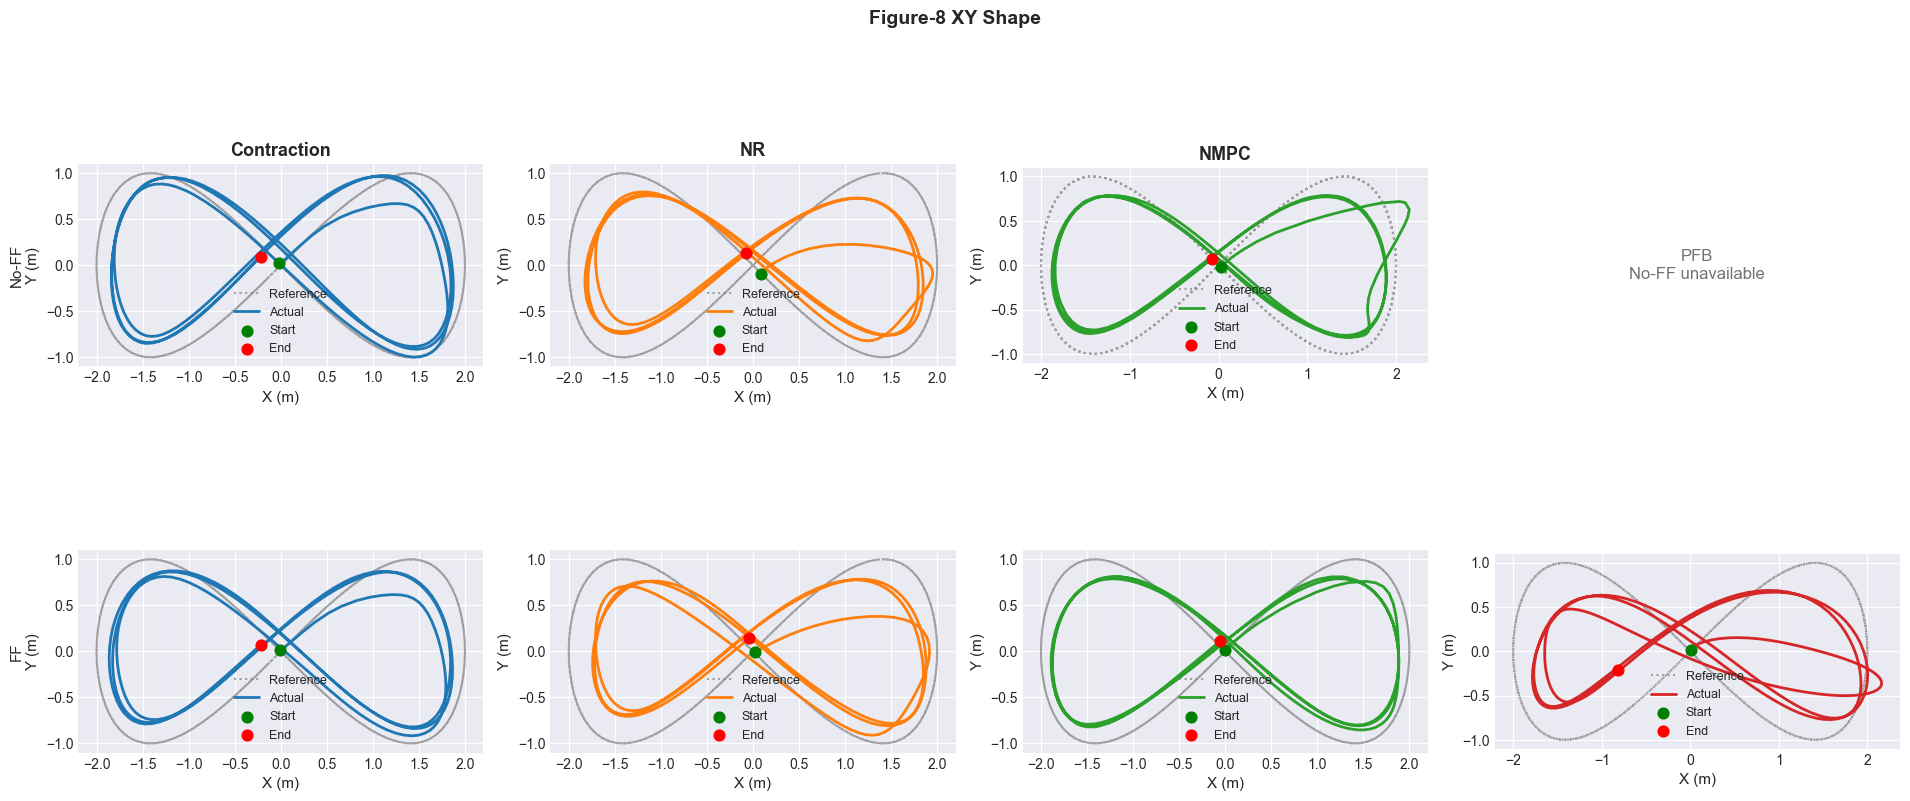

In [ ]:
fig, axes = plt.subplots(len(FF_VARIANTS), len(CONTROLLERS), figsize=(4.8 * len(CONTROLLERS), 9), squeeze=False)

for row, ff in enumerate(FF_VARIANTS):
    for col, ctrl in enumerate(CONTROLLERS):
        ax = axes[row, col]

        if ff not in data.get(ctrl, {}):
            ax.set_axis_off()
            ax.text(0.5, 0.5, f'{ctrl}\n{ff} unavailable', ha='center', va='center', fontsize=12, color='0.45')
            continue

        df = data[ctrl][ff]
        color = CTRL_COLOR[ctrl]

        ax.plot(df['x_ref'], df['y_ref'], color='grey', lw=1.5, ls=':', alpha=0.7, label='Reference')
        ax.plot(df['x'],     df['y'],     color=color,  lw=2.0, label='Actual')
        ax.scatter(df['x'].iloc[0],  df['y'].iloc[0],  color='green', zorder=5, s=60, label='Start')
        ax.scatter(df['x'].iloc[-1], df['y'].iloc[-1], color='red',   zorder=5, s=60, label='End')

        ax.set_xlabel('X (m)', fontsize=11)
        ax.set_ylabel('Y (m)', fontsize=11)
        ax.set_aspect('equal')
        ax.legend(fontsize=9)

        if row == 0:
            ax.set_title(ctrl, fontsize=13, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'{ff}\nY (m)', fontsize=11)

fig.suptitle('Figure-8 XY Shape', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## RMSE Comparison

Position RMSE = √( (x−x_ref)² + (y−y_ref)² + (z−z_ref)² )

In [ ]:
def _lookahead(df):
    return float(df['lookahead_time'].iloc[0]) if 'lookahead_time' in df.columns else 0.0

def axis_error(df, col):
    """Return (errors, valid_mask) accounting for NR lookahead.

    NR controllers target output(t+lookahead) = ref(t), so the meaningful
    error is actual(t+lookahead) - ref(t).  For lookahead=0 this is just
    actual(t) - ref(t).
    """
    lookahead = _lookahead(df)
    t      = df['time'].values
    actual = df[col].values
    ref    = df[f'{col}_ref'].values
    if lookahead == 0.0:
        return actual - ref, np.ones(len(t), dtype=bool)
    valid   = (t + lookahead) <= t[-1]
    shifted = np.interp(t[valid] + lookahead, t, actual)
    return shifted - ref[valid], valid

def position_rmse(df):
    ex, _ = axis_error(df, 'x')
    ey, _ = axis_error(df, 'y')
    ez, _ = axis_error(df, 'z')
    return float(np.sqrt((ex**2 + ey**2 + ez**2).mean()))

def per_axis_rmse(df):
    return {ax: float(np.sqrt((axis_error(df, ax)[0]**2).mean())) for ax in ['x', 'y', 'z']}

# Build results table: list of (ctrl, ff, pos_rmse, per_axis_rmse_dict)
results = []
for ctrl in CONTROLLERS:
    for ff in AVAILABLE_VARIANTS[ctrl]:
        df = data[ctrl][ff]
        results.append((ctrl, ff, position_rmse(df), per_axis_rmse(df)))

metric_lookup = {(ctrl, ff): (pos_r, ax_r) for ctrl, ff, pos_r, ax_r in results}

# --- Print table ---
col_w = 14
header = f"{'Controller':<14}{'Variant':<8}" + "".join(f"{'RMSE '+a:>{col_w}}" for a in ['X','Y','Z','XYZ'])
print(header)
print('-' * len(header))
for ctrl, ff, pos_r, ax_r in results:
    note = '*' if _lookahead(data[ctrl][ff]) > 0 else ''
    print(f"{ctrl:<14}{ff:<8}" +
          "".join(f"{ax_r[a]:>{col_w}.4f}" for a in ['x','y','z']) +
          f"{pos_r:>{col_w}.4f}{note}")
print("\n* NR RMSE uses shifted error: actual(t+lookahead) - ref(t)")

Controller    Variant         RMSE X        RMSE Y        RMSE Z      RMSE XYZ
------------------------------------------------------------------------------
Contraction   No-FF           0.1559        0.1551        0.0863        0.2362
Contraction   FF              0.1517        0.1728        0.0738        0.2415
NR            No-FF           0.1524        0.2387        0.6252        0.6864*
NR            FF              0.1596        0.2177        0.6270        0.6826*
NMPC          No-FF           0.1574        0.2028        0.0497        0.2615
NMPC          FF              0.1402        0.1843        0.0395        0.2349
PFB           FF              0.2508        0.3379        0.8290        0.9297

* NR RMSE uses shifted error: actual(t+lookahead) - ref(t)


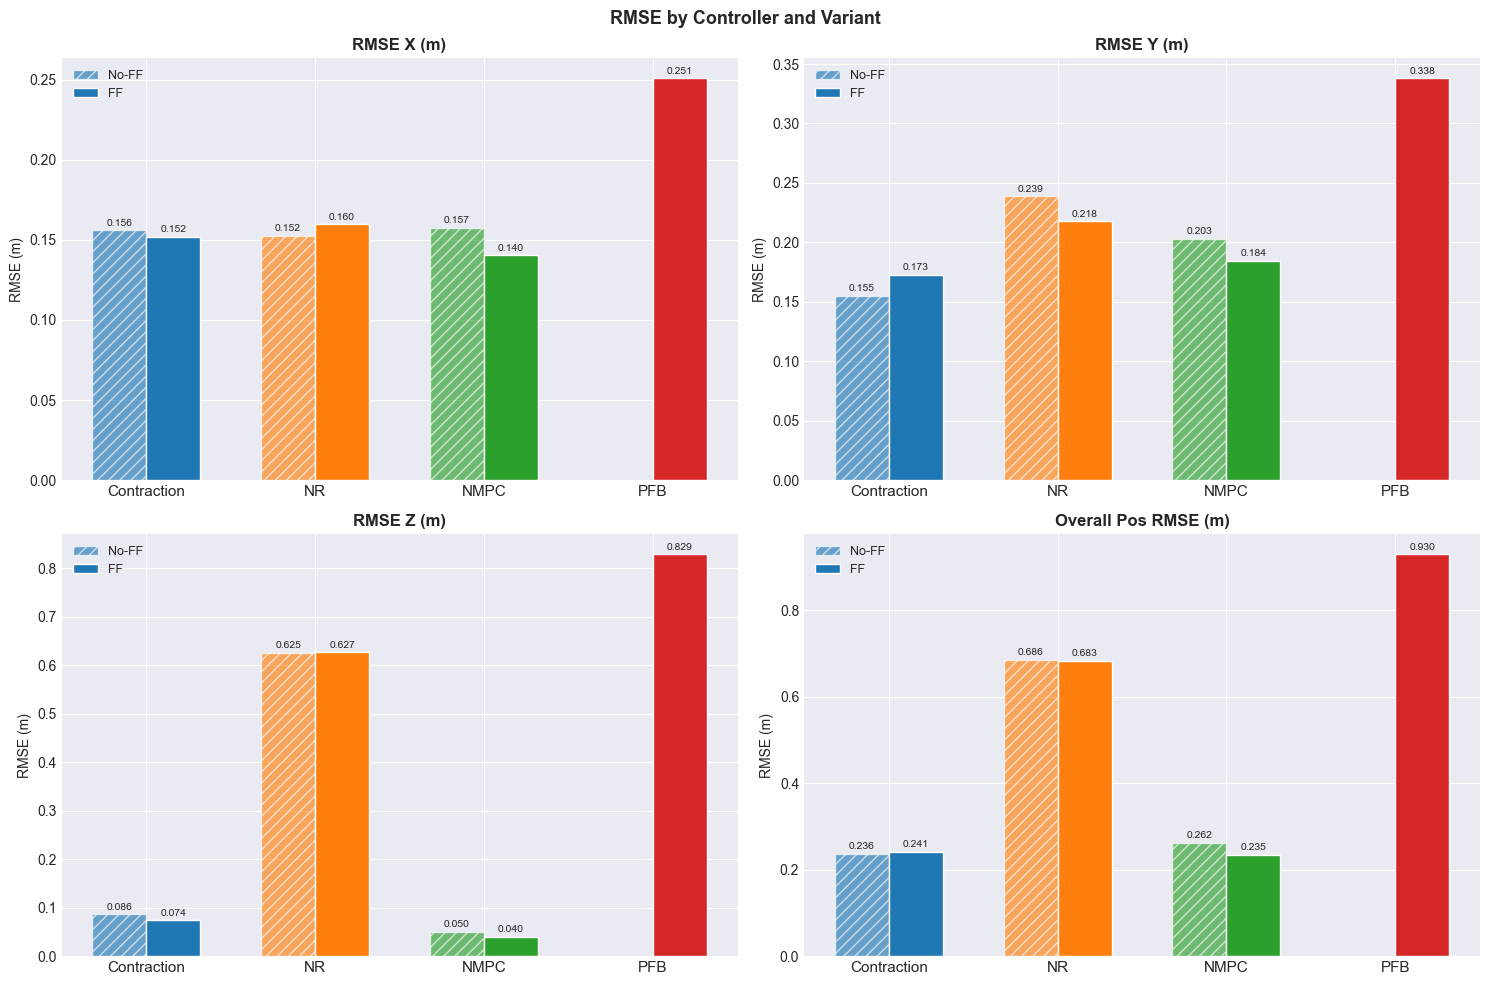

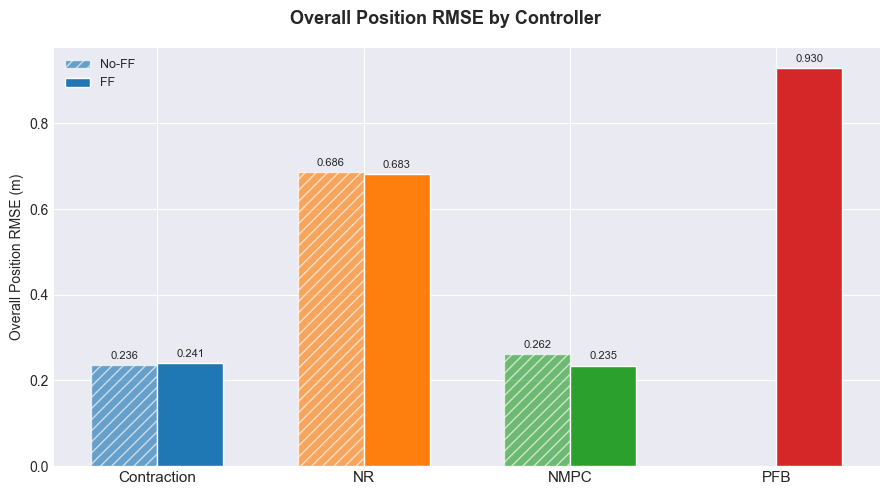

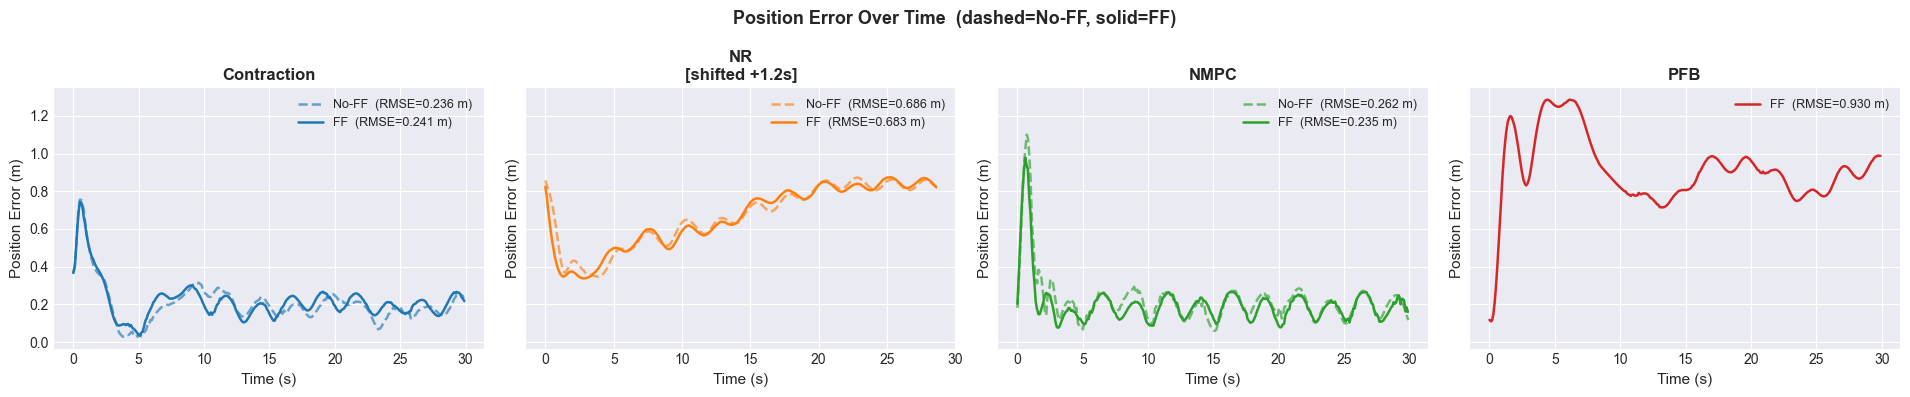

In [ ]:
# -- RMSE grouped bar chart (2x2: one subplot per axis + overall) -----------
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
axis_keys = [('x', 'RMSE X (m)'), ('y', 'RMSE Y (m)'), ('z', 'RMSE Z (m)'), (None, 'Overall Pos RMSE (m)')]

x      = np.arange(len(CONTROLLERS))
width  = 0.32
offset = {'No-FF': -width/2, 'FF': width/2}

for subplot_ax, (key, title) in zip(axes, axis_keys):
    for ff in FF_VARIANTS:
        vals = []
        labels = []
        for ctrl in CONTROLLERS:
            entry = metric_lookup.get((ctrl, ff))
            if entry is None:
                vals.append(np.nan)
                labels.append('')
            else:
                pos_r, ax_r = entry
                val = pos_r if key is None else ax_r[key]
                vals.append(val)
                labels.append(f'{val:.3f}')
        colors = [CTRL_COLOR[c] for c in CONTROLLERS]
        bars = subplot_ax.bar(
            x + offset[ff], vals, width,
            color=colors, alpha=FF_ALPHA[ff],
            hatch=FF_HATCH[ff], edgecolor='white',
            label=ff
        )
        subplot_ax.bar_label(bars, labels=labels, fontsize=7.5, padding=2)

    subplot_ax.set_xticks(x)
    subplot_ax.set_xticklabels(CONTROLLERS, fontsize=11)
    subplot_ax.set_ylabel('RMSE (m)', fontsize=10)
    subplot_ax.set_title(title, fontsize=12, fontweight='bold')
    subplot_ax.legend(fontsize=9)

fig.suptitle('RMSE by Controller and Variant',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# -- Overall RMSE grouped bar chart only --------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(9, 5))

for ff in FF_VARIANTS:
    vals = []
    labels = []
    for ctrl in CONTROLLERS:
        entry = metric_lookup.get((ctrl, ff))
        if entry is None:
            vals.append(np.nan)
            labels.append('')
        else:
            pos_r, _ = entry
            vals.append(pos_r)
            labels.append(f'{pos_r:.3f}')
    colors = [CTRL_COLOR[c] for c in CONTROLLERS]
    bars = ax.bar(
        x + offset[ff], vals, width,
        color=colors, alpha=FF_ALPHA[ff],
        hatch=FF_HATCH[ff], edgecolor='white',
        label=ff
    )
    ax.bar_label(bars, labels=labels, fontsize=8, padding=3)

ax.set_xticks(x)
ax.set_xticklabels(CONTROLLERS, fontsize=11)
ax.set_ylabel('Overall Position RMSE (m)', fontsize=10)
ax.legend(fontsize=9)

fig.suptitle('Overall Position RMSE by Controller',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# -- Time-series position error: one column per controller; available variants overlaid --
fig, axes = plt.subplots(1, len(CONTROLLERS), figsize=(4.8 * len(CONTROLLERS), 4), sharey=True, squeeze=False)
axes = axes[0]

for ax, ctrl in zip(axes, CONTROLLERS):
    for ff in AVAILABLE_VARIANTS[ctrl]:
        df = data[ctrl][ff]
        ex, valid = axis_error(df, 'x')
        ey, _     = axis_error(df, 'y')
        ez, _     = axis_error(df, 'z')
        t_plot    = df['time'].values[valid]
        err       = np.sqrt(ex**2 + ey**2 + ez**2)
        rmse_val  = float(np.sqrt((err**2).mean()))

        ax.plot(t_plot, err,
                color=CTRL_COLOR[ctrl], lw=1.8,
                ls=FF_LINESTYLE[ff], alpha=FF_ALPHA[ff],
                label=f'{ff}  (RMSE={rmse_val:.3f} m)')

    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_ylabel('Position Error (m)', fontsize=11)
    ref_variant = 'FF' if 'FF' in AVAILABLE_VARIANTS[ctrl] else AVAILABLE_VARIANTS[ctrl][0]
    la = _lookahead(data[ctrl][ref_variant])
    suffix = f'\n[shifted +{la}s]' if la > 0 else ''
    ax.set_title(ctrl + suffix, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

fig.suptitle('Position Error Over Time  (dashed=No-FF, solid=FF)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Computation Time

Average `comp_time` for each controller / variant.

Controller    Variant    Mean (ms)    Std (ms)    Max (ms)
----------------------------------------------------------
Contraction   No-FF          0.302       0.186       2.504
Contraction   FF             0.340       0.173       2.626
NR            No-FF          0.059       0.034       0.265
NR            FF             0.129       0.073       0.407
NMPC          No-FF         11.250       7.153      25.014
NMPC          FF             7.740       3.139      24.467
PFB           FF             3.374       2.253      11.241


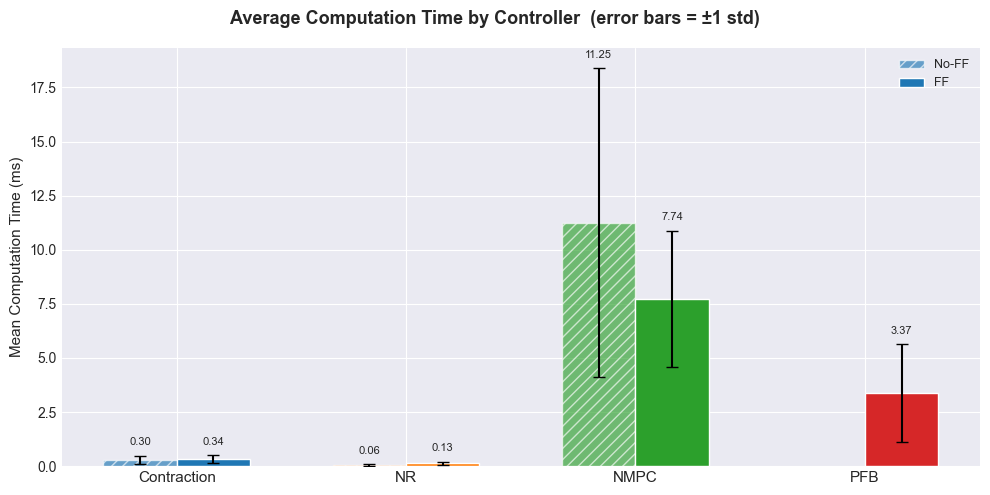

In [ ]:
# --- Computation time table ---
print(f"{'Controller':<14}{'Variant':<8}{'Mean (ms)':>12}{'Std (ms)':>12}{'Max (ms)':>12}")
print('-' * 58)

comp_lookup = {}
for ctrl in CONTROLLERS:
    for ff in AVAILABLE_VARIANTS[ctrl]:
        df = data[ctrl][ff]
        if 'comp_time' not in df.columns:
            print(f"{ctrl:<14}{ff:<8}{'N/A':>12}")
            continue
        ct_ms = df['comp_time'] * 1e3  # assume seconds → ms; if already ms this still plots consistently
        mean_ct = ct_ms.mean()
        std_ct  = ct_ms.std()
        max_ct  = ct_ms.max()
        comp_lookup[(ctrl, ff)] = (mean_ct, std_ct, max_ct)
        print(f"{ctrl:<14}{ff:<8}{mean_ct:>12.3f}{std_ct:>12.3f}{max_ct:>12.3f}")

# --- Bar chart ---
fig, ax = plt.subplots(figsize=(10, 5))

x      = np.arange(len(CONTROLLERS))
width  = 0.32
offset = {'No-FF': -width/2, 'FF': width/2}

for ff in FF_VARIANTS:
    means  = []
    stds   = []
    labels = []
    for ctrl in CONTROLLERS:
        entry = comp_lookup.get((ctrl, ff))
        if entry is None:
            means.append(np.nan)
            stds.append(0)
            labels.append('')
        else:
            mean_ct, std_ct, _ = entry
            means.append(mean_ct)
            stds.append(std_ct)
            labels.append(f'{mean_ct:.2f}')

    colors = [CTRL_COLOR[c] for c in CONTROLLERS]
    bars = ax.bar(
        x + offset[ff], means, width,
        yerr=stds, capsize=4,
        color=colors, alpha=FF_ALPHA[ff],
        hatch=FF_HATCH[ff], edgecolor='white',
        label=ff
    )
    ax.bar_label(bars, labels=labels, fontsize=8, padding=6)

ax.set_xticks(x)
ax.set_xticklabels(CONTROLLERS, fontsize=11)
ax.set_ylabel('Mean Computation Time (ms)', fontsize=11)
ax.legend(fontsize=9)
fig.suptitle('Average Computation Time by Controller  (error bars = ±1 std)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()